# Structure: building lattice geometries in pyqula
This notebook shows how to build the atomic/lattice structure that every pyqula calculation starts from: a `Geometry` (positions + lattice vectors), and the tight-binding `Hamiltonian` built on top of it.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

### The Geometry object
A `Geometry` stores the atomic positions in the unit cell $\{\mathbf{r}_i\}$ and the Bravais lattice vectors $\mathbf{a}_1,\mathbf{a}_2,\dots$ (as many as the dimensionality). From the real-space hoppings $H_{\mathbf n}$ between a cell and its neighboring cell at lattice vector $\mathbf n$, pyqula builds the Bloch Hamiltonian
$$ H(\mathbf k) = \sum_{\mathbf n} H_{\mathbf n}\, e^{i\mathbf k\cdot \mathbf n} $$
used for band structures, DOS, topology, etc.

In [2]:
g_chain = geometry.chain()          # 1D, 1 atom per cell
g_honey = geometry.honeycomb_lattice()  # 2D, 2 atoms per cell (bipartite)
g_kagome = geometry.kagome_lattice()    # 2D, 3 atoms per cell (line-graph lattice)

for name,g in [("chain",g_chain),("honeycomb",g_honey),("kagome",g_kagome)]:
    print(f"{name:10s}  dimensionality={g.dimensionality}  atoms/cell={len(g.r)}")

chain       dimensionality=1  atoms/cell=1
honeycomb   dimensionality=2  atoms/cell=2
kagome      dimensionality=2  atoms/cell=3


### Visualize a supercell of each lattice in real space
`get_supercell(n)` repeats the unit cell to make the periodicity visible.

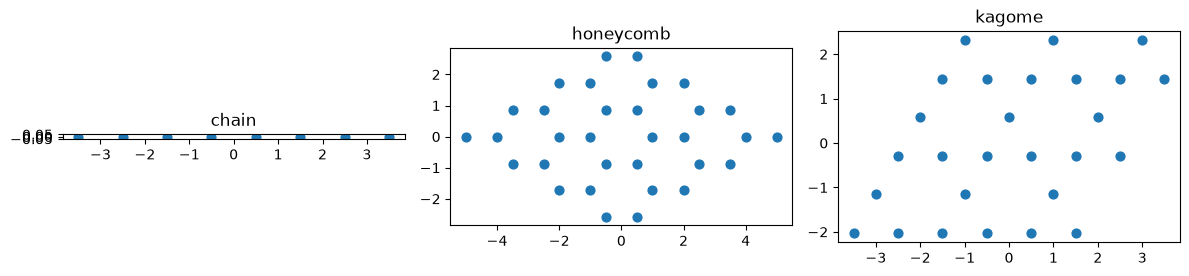

In [3]:
fig, axes = plt.subplots(1,3,figsize=(12,4))
for ax,(name,g,n) in zip(axes,[("chain",g_chain,8),("honeycomb",g_honey,4),("kagome",g_kagome,3)]):
    gs = g.get_supercell(n)
    ax.scatter(gs.x, gs.y, s=40)
    ax.set_title(name)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### From geometry to Hamiltonian
`get_hamiltonian()` builds the tight-binding Hamiltonian on a `Geometry`, by default first-neighbor hopping $H=\sum_{\langle ij\rangle} c^\dagger_i c_j$. The real-space hoppings are stored keyed by lattice vector $\mathbf n$.

In [4]:
h = g_honey.get_hamiltonian()
print("onsite block h(0,0,0) shape:", h.intra.shape)

hop = h.get_multihopping()          # dict {(n1,n2,n3): hopping matrix}
keys = sorted(tuple(int(ni) for ni in n) for n in hop.dict.keys())
print("lattice vectors with nonzero hopping:", keys)

onsite block h(0,0,0) shape: (4, 4)
lattice vectors with nonzero hopping: [(-1, -1, 0), (-1, 0, 0), (-1, 1, 0), (0, -1, 0), (0, 0, 0), (0, 1, 0), (1, -1, 0), (1, 0, 0), (1, 1, 0)]
